

# Li-6 polarized atomic beam source design notebook

This notebook provides a **physics-based baseline model** for a polarized $^6$Li atomic beam source with:

- effusive oven source at **600 °C**,
- long circular oven tube (length 10 cm, inner diameter 7 mm),
- optional transverse cooling,
- optional 2D-MOT-like transverse compression,
- spatially resolved optical pumping,
- RF transition design near **100 G**,
- downstream circular acceptance aperture about **80 cm** from the oven exit,
- figures of merit based on accepted flux and accepted tensor polarization.

The notebook is intended for **design studies and parameter scans**, not as a final precision simulator. In particular:

- the beamline transport is represented with a Monte Carlo ensemble,
- the 2D-MOT is represented by a reduced effective model,
- the optical pumping block uses a **rate-based effective pumping model** rather than a full optical Bloch solver,
- the RF block uses a reduced transition model with a state-transfer matrix,
- the internal-state basis is built around the six nuclear-spin projections $m_I \in \{-1,0,+1\}$ combined with electronic-spin projections $m_S=\pm1/2$.

That makes the notebook suitable for rapid iteration and optimization before committing to a heavier exact treatment.


In [31]:
# Enable automatic reloading of modules so that changes in external Python files are reflected without restarting the notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from dataclasses import dataclass, replace
from scipy.constants import k as k_B, h, c, atomic_mass
from scipy.special import erf
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
import warnings
from skopt import gp_minimize
from skopt.space import Real
from functools import partial

# Importing custom modules for the lithium beam simulation
import li6_polarized_source_functions as li

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(12345)


## 1. Physical constants and source configuration

We use:

- $^6$Li mass from the isotope mass,
- nuclear spin $I=1$,
- a starting oven temperature of **600 °C**,
- a tube of length **10 cm** and inner diameter **7 mm**,
- a downstream acceptance orifice located **80 cm** from the tube exit.

Temperature averages are used wherever an average thermal speed or mean longitudinal velocity is needed.


In [58]:
# constants
amu = atomic_mass
m_Li6 = 6.0151228874 * amu      # kg
I_nuclear = 1

# Approximate D-line wavelength scale used for beam/laser geometry estimates
lambda_D = 670.977e-9           # m (representative Li D-line scale)
k_laser = 2*np.pi/lambda_D
nu_laser = c / lambda_D

# Natural scale; used only in the effective pumping model
Gamma_eff = 2*np.pi * 5.9e6     # rad/s, representative linewidth scale

# Magnetic moments (reduced design-model values)
gS = 2.0023
gI_Li6 = 0.0004476540

cfg = li.SourceConfig(N_atoms=int(5e6), 
    tube_length=0.1, tube_radius=3.5e-3,
    # tube_length=.0549, tube_radius=1.423e-3,
    capillary_length=7.709e-3, capillary_radius=0.083e-3,
    z_orifice=3, orifice_radius=5e-3,
    T_oven_C=600.0,
    n_exit_m3=None)
T_oven_K = cfg.T_oven_C + 273.15
print(cfg)
print("T_oven [K] =", T_oven_K)

SourceConfig(T_oven_C=600.0, oven_channel_radius=0.02, tube_length=0.1, tube_radius=0.0035, z_orifice=3, orifice_radius=0.005, N_atoms=5000000, capillary_outer_radius=0.000105, number_of_capillaries=800, array_radius=0.0025, array_shape='hex', capillary_length=0.007709, capillary_radius=8.3e-05, z_cooling_start=0.02, z_cooling_end=0.18, z_mot_start=0.18, z_mot_end=0.33, z_pump_start=0.34, z_pump_end=0.48, z_rf_start=0.5, z_rf_end=0.57, n_exit_m3=None, cooling_enabled=True, cooling_vt_scale=0.45, mot_enabled=True, mot_capture_radius=0.007, mot_capture_vt=55.0, mot_compression_factor=0.35, mot_vt_factor=0.28, pump_enabled=True, pump_power_W=0.12, pump_detuning_MHz=0.0, pump_shape='elliptical_gaussian', pump_wx=0.004, pump_wy=0.0025, pump_polarization='sigma0', pump_repump_fraction=0.18, pump_target='mi_abs1', pump_rate_scale=1.0, optical_thickness_enabled=False, sigma_abs_eff=1e-15, rf_enabled=True, B_RF_G=100.0, rf_B1_G=0.45, rf_detuning_MHz=0.0, rf_target='mi_abs1', rf_transition_stren

<unknown>:868: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<unknown>:879: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.



## 2. Thermal speed scales and simple effusive-beam averages

For a thermal source, we will use:

- average speed:
  $$
  \bar v = \sqrt{\frac{8k_B T}{\pi m}}
  $$
- most probable speed:
  $$
  v_{mp} = \sqrt{\frac{2k_B T}{m}}
  $$
- rms speed:
  $$
  v_{rms} = \sqrt{\frac{3k_B T}{m}}
  $$

For the outgoing **effusive** beam, the longitudinally weighted distribution is more forward-directed than the 3D Maxwell distribution. We use Monte Carlo sampling of the flux-weighted angular and speed distributions below.


In [59]:
v_mp, v_mean, v_rms = li.thermal_speeds(T_oven_K, m_Li6)
print(f"v_mp   = {v_mp:8.2f} m/s")
print(f"v_mean = {v_mean:8.2f} m/s")
print(f"v_rms  = {v_rms:8.2f} m/s")

v_mp   =  1553.65 m/s
v_mean =  1753.11 m/s
v_rms  =  1902.83 m/s



## 3. Internal-state basis for $^6$Li

We use a six-state basis:
$$
(m_S, m_I) \in \left\{\left(+\tfrac12,-1\right),\left(+\tfrac12,0\right),\left(+\tfrac12,+1\right),
\left(-\tfrac12,-1\right),\left(-\tfrac12,0\right),\left(-\tfrac12,+1\right)\right\}.
$$

This basis is useful because your final design goal is expressed in terms of the **nuclear-spin projections**
$m_I=\pm1$ and $m_I=0$.

At high field, this basis is intuitive. At intermediate field, including around 100 G, the exact eigenstates are mixed. In this baseline notebook we model the RF section with a reduced mixing and transfer matrix rather than a full exact diagonalization.


In [60]:
STATE_LABELS = li.state_labels()
N_STATES = len(STATE_LABELS)

for i, st in enumerate(STATE_LABELS):
    print(i, st)

0 (0.5, -1)
1 (0.5, 0)
2 (0.5, 1)
3 (-0.5, -1)
4 (-0.5, 0)
5 (-0.5, 1)



## 4. Effusive source sampler through a long tube

We model the oven output in two steps:

1. sample a point inside the exit aperture,
2. sample a flux-weighted thermal velocity,
3. reject trajectories that would have collided with the tube wall when back-propagated through the length of the tube.

This gives a simple long-tube collimation model.


In [61]:
beam0 = li.sample_effusive_beam(cfg, rng)
print("Sampled atoms:", len(beam0["x"]))
print("Transmission frequency:", len(beam0["x"])/cfg.N_atoms * 100, "%")
print("Mean vz:", beam0["vz"].mean())
print("Mean transverse speed:", np.sqrt(beam0["vx"]**2 + beam0["vy"]**2).mean())

Sampled atoms: 6249
Transmission frequency: 0.12498 %
Mean vz: 2053.54144005745
Mean transverse speed: 65.69153646014001


# Sampler through a Hexagonal Parallel Capillary Array

In [62]:
rejection_multi_capillary = li.rejection_sampling_multi_capillary(cfg, rng)
print("Sampled atoms:", len(rejection_multi_capillary["x"]))
print(f"Transmission efficiency: {rejection_multi_capillary['transmission_probability'] * 100:.3f}%")
print(f"Mean vz: {rejection_multi_capillary['vz'].mean()}")
print(f"Mean transverse speed: {np.sqrt(rejection_multi_capillary['vx']**2 + rejection_multi_capillary['vy']**2).mean()}")


Attempted: 5000000 | Transmitted: 474
Total Array Transmission Efficiency: 0.009%
Sampled atoms: 474
Transmission efficiency: 0.009%
Mean vz: 2051.573977407379
Mean transverse speed: 19.653807373814995


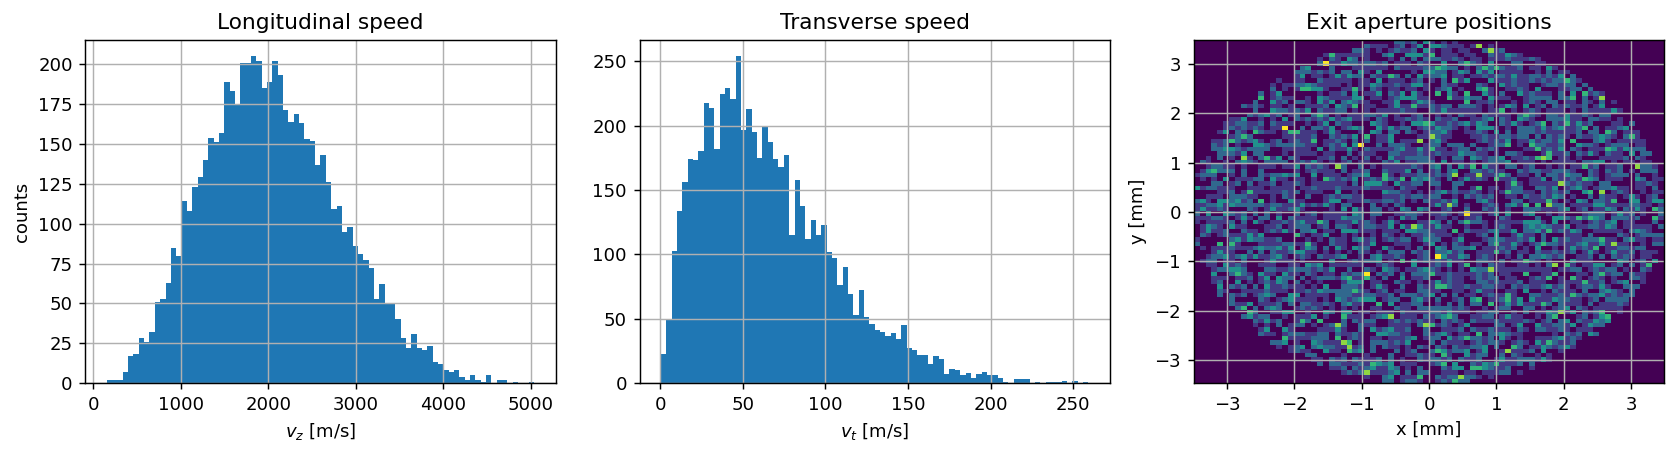

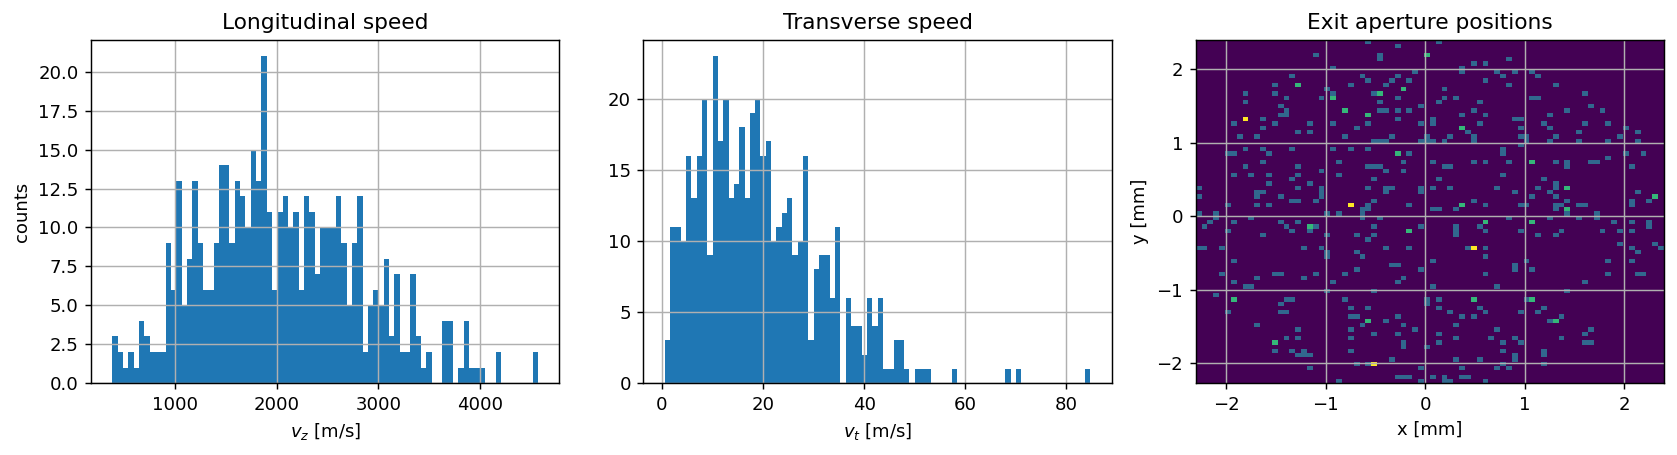

In [63]:
li.plot_source_distributions(beam0)
li.plot_source_distributions(rejection_multi_capillary)


## 14. End-to-end simulation wrapper


In [67]:
res = li.run_simulation(cfg, rng)
print("Source flux estimate      :", f"{res['flux_source']:.3e} atoms/s")
print("Accepted fraction         :", f"{res['frac_acc']:.3e}")
print("Accepted flux             :", f"{res['flux_acc']:.3e} atoms/s")
print("Accepted Pz               :", f"{res['pol_acc']['Pz']:.4f}")
print("Accepted Pzz              :", f"{res['pol_acc']['Pzz']:.4f}")
print("Accepted flux * |Pzz|     :", f"{res['FOM_absPzz']:.3e}")
print("\n")
res2 = li.run_simulation(cfg, rng, aperture_type='multi_capillary')
print("Source flux estimate      :", f"{res2['flux_source']:.3e} atoms/s")
print("Accepted fraction         :", f"{res2['frac_acc']:.3e}")
print("Accepted flux             :", f"{res2['flux_acc']:.3e} atoms/s")
print("Accepted Pz               :", f"{res2['pol_acc']['Pz']:.4f}")
print("Accepted Pzz              :", f"{res2['pol_acc']['Pzz']:.4f}")
print("Accepted flux * |Pzz|     :", f"{res2['FOM_absPzz']:.3e}")


<unknown>:879: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<unknown>:888: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.


Source flux estimate      : 3.011e+20 atoms/s
Accepted fraction         : 3.724e-06
Accepted flux             : 1.121e+15 atoms/s
Accepted Pz               : 0.0000
Accepted Pzz              : 0.7405
Accepted flux * |Pzz|     : 8.302e+14


Attempted: 5000000 | Transmitted: 482
Total Array Transmission Efficiency: 0.010%
Source flux estimate      : 3.011e+20 atoms/s
Accepted fraction         : 1.016e-06
Accepted flux             : 3.058e+14 atoms/s
Accepted Pz               : 0.0000
Accepted Pzz              : 0.7384
Accepted flux * |Pzz|     : 2.258e+14



## 15. Diagnostics and plots


In [68]:
li.summary_table(res)


=== Beamline summary ===
Source flux estimate       : 3.0108e+20 atoms/s
Accepted fraction          : 3.7240e-06
Oven exit flux              : 1.1433e+16 atoms/s
Accepted flux              : 1.1212e+15 atoms/s

All atoms at orifice plane:
   Nm1 =  0.43469
    N0 =  0.13061
   Np1 =  0.43469
    Pz =  0.00000
   Pzz =  0.60816

Accepted atoms only:
   Nm1 =  0.45674
    N0 =  0.08652
   Np1 =  0.45674
    Pz =  0.00000
   Pzz =  0.74045

FOM = flux_acc * |Pzz|     : 8.3021e+14


In [69]:
li.summary_table(res2)

=== Beamline summary ===
Source flux estimate       : 3.0108e+20 atoms/s
Accepted fraction          : 1.0156e-06
Oven exit flux              : 4.5350e+14 atoms/s
Accepted flux              : 3.0578e+14 atoms/s

All atoms at orifice plane:
   Nm1 =  0.45506
    N0 =  0.08989
   Np1 =  0.45506
    Pz =  0.00000
   Pzz =  0.73033

Accepted atoms only:
   Nm1 =  0.45640
    N0 =  0.08719
   Np1 =  0.45640
    Pz =  0.00000
   Pzz =  0.73842

FOM = flux_acc * |Pzz|     : 2.2580e+14


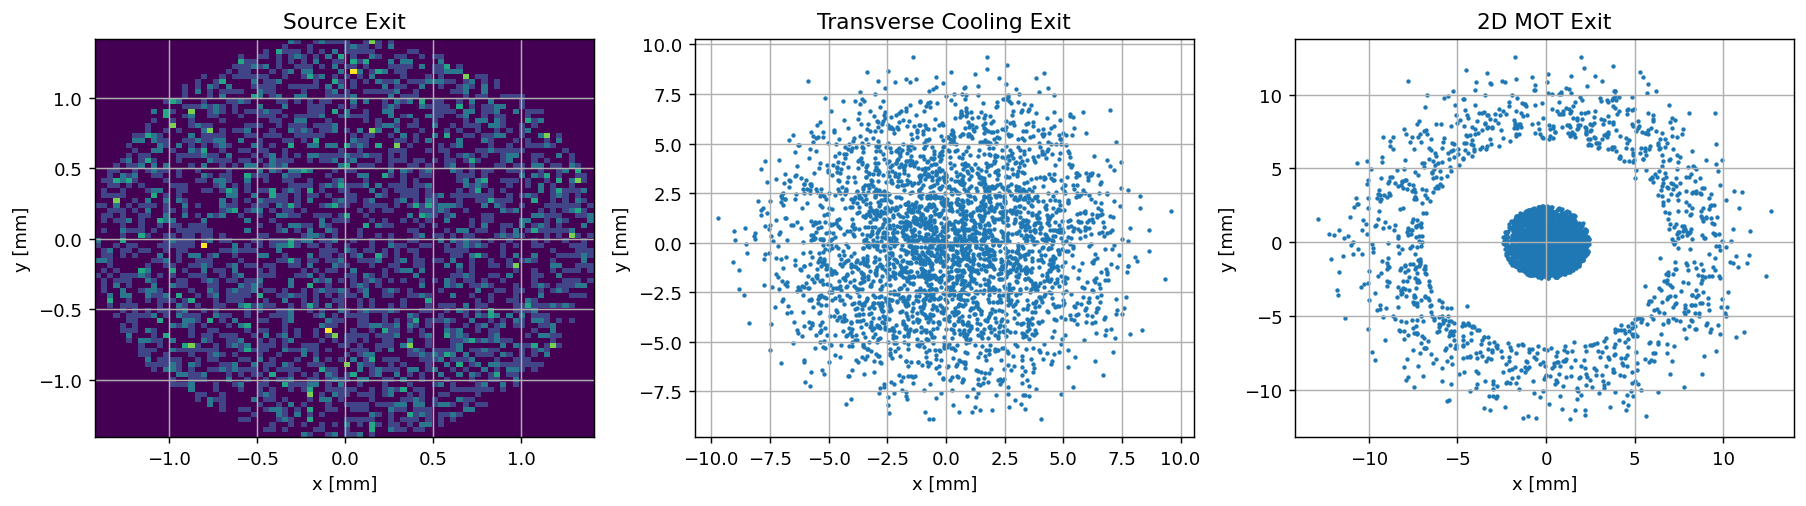

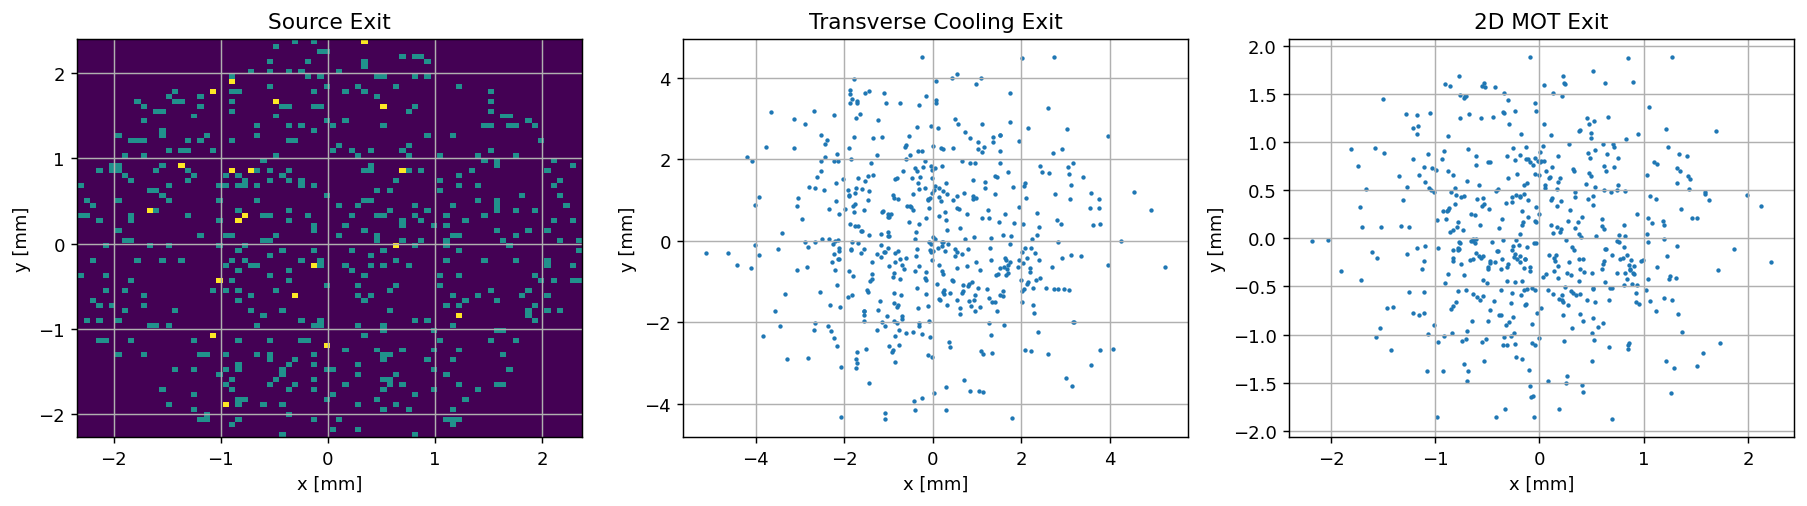

In [44]:
li.plot_cooling_cross_sections(res)
li.plot_cooling_cross_sections(res2)

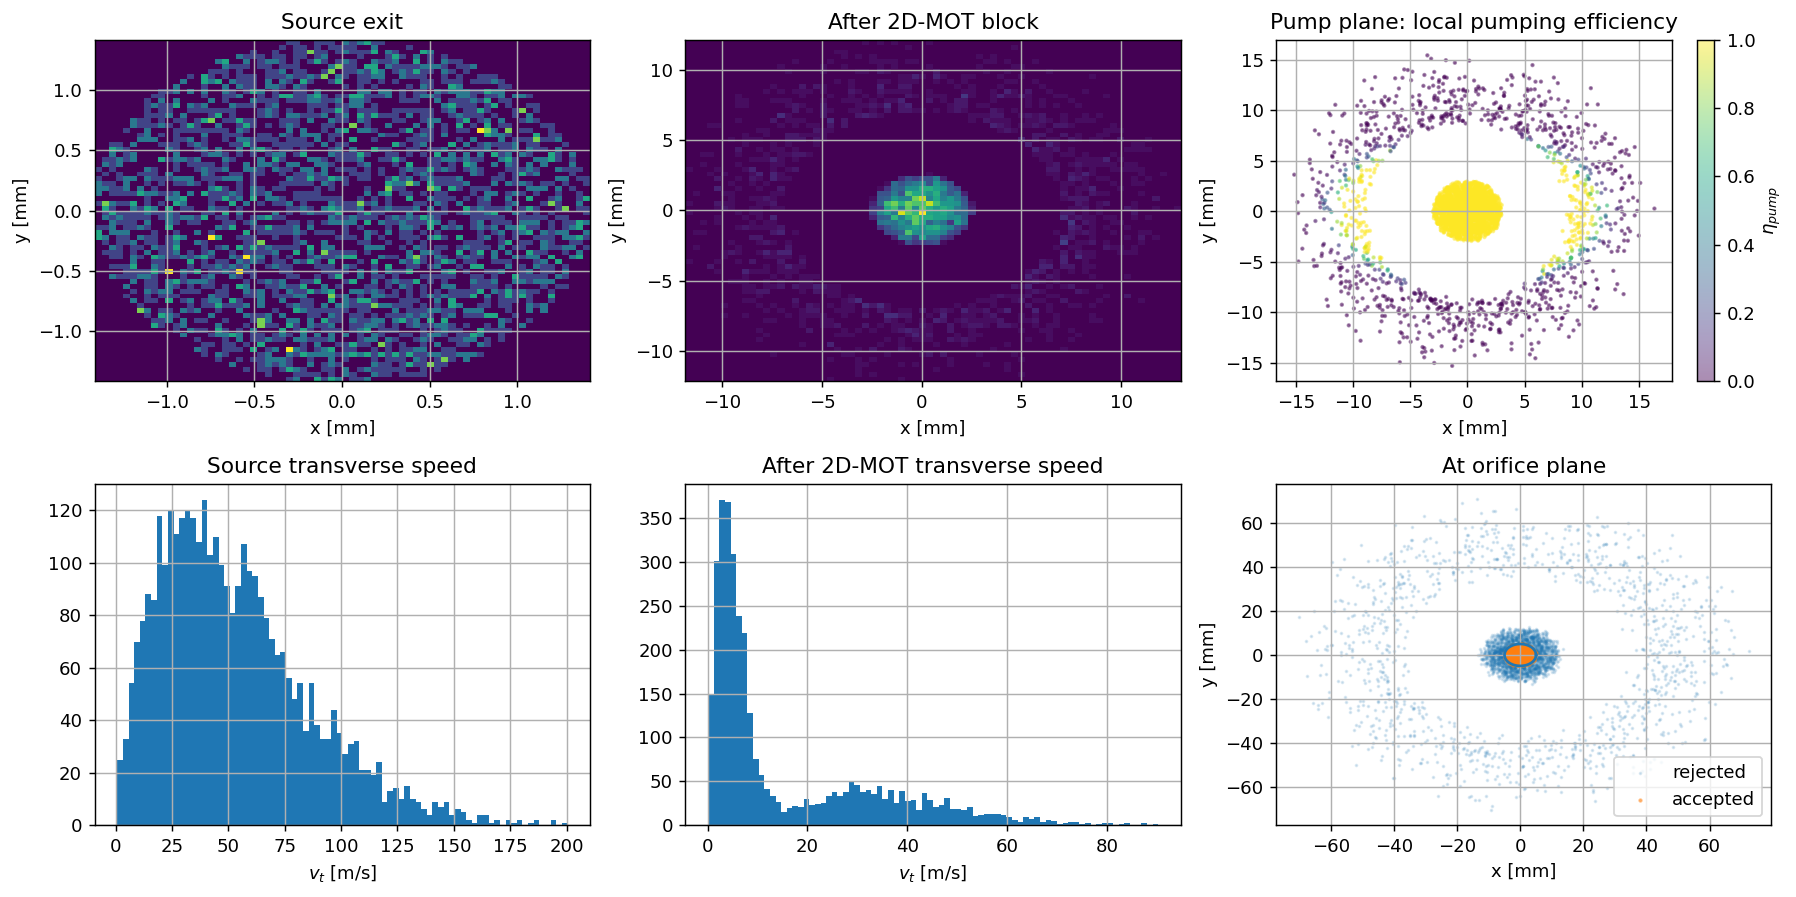

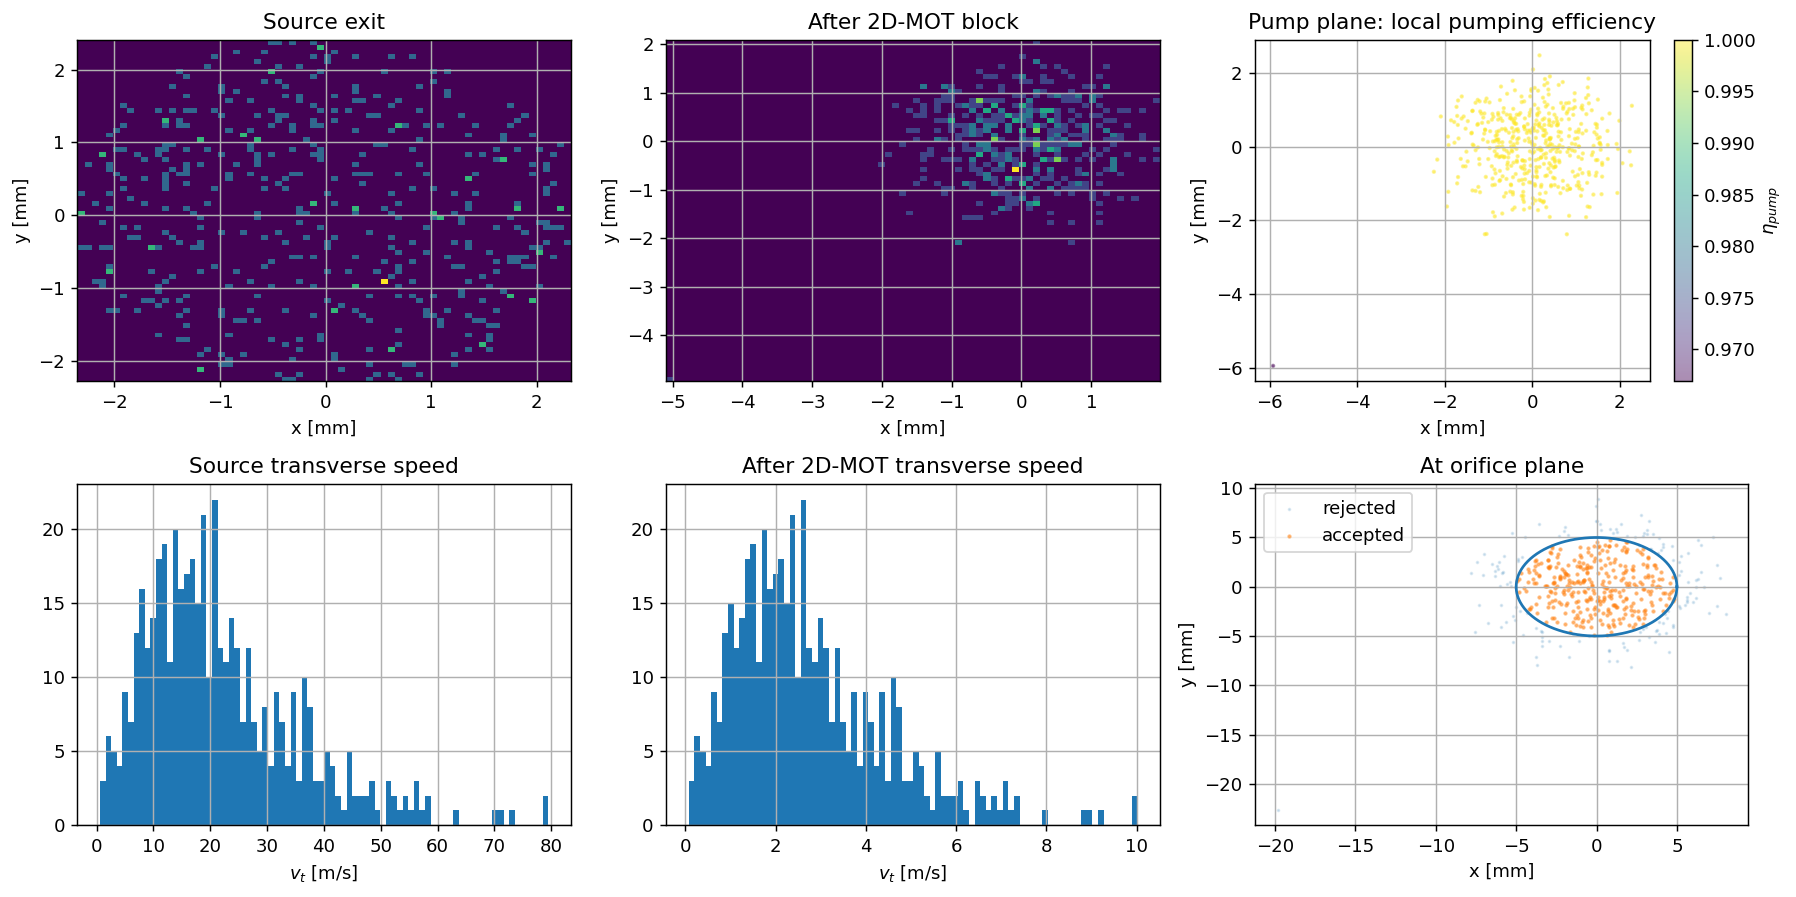

In [ ]:
li.plot_beamline_maps(res, cfg)
li.plot_beamline_maps(res2, cfg)

# Using Scikit Optimize to optimize parameters for Tube and Capillary Array

In [13]:
capillary_search_space = [
    Real(1.0, 10.0, name='capillary_length_mm'),
    Real(0.01, 0.1, name='capillary_radius_mm')
]

cfg_local = replace(cfg)
# cfg_local.T_oven_C = 600.0

objective = partial(
    li.objective,
    cfg_base=cfg_local,
    aperture_type='multi_capillary',
    min_flux=1e14,
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", message=".*ConvergenceWarning.*")
    with np.errstate(all="ignore"):
        res = gp_minimize(
            objective,
            dimensions=capillary_search_space,
            acq_func='EI',
            n_calls=100,
            random_state=35
        )

best_length_mm, best_radius_mm = res.x
best_theta = res.fun

best_length_mm, best_radius_mm = res.x

cfg_best = replace(cfg)
cfg_best.capillary_length = best_length_mm * 1e-3
cfg_best.capillary_radius = best_radius_mm * 1e-3

best_theta, best_flux = li.simulation_for_optimizer(
    cfg_best,
    rng=np.random.default_rng(35),
    aperture_type='multi_capillary',
    parameter_to_optimize='theta'
)

print(f'Best capillary_length_mm = {best_length_mm:.4f}')
print(f'Best capillary_radius_mm = {best_radius_mm:.5f}')
print(f'Best theta95 = {best_theta:.6g}')
print(f'Final accepted flux = {best_flux:.3e} atoms/s')

Best capillary_length_mm = 5.0482
Best capillary_radius_mm = 0.07089
Best theta95 = 0.0228625
Final accepted flux = 7.229e+13 atoms/s


In [45]:
tube_search_space = [
    Real(1, 90, name='tube_length_mm'),
    Real(0.1, 10, name='tube_radius_mm')
]

objective = partial(
    li.objective,
    cfg_base=cfg,
    aperture_type='long_tube',
    min_flux=1.3e14,
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", message=".*ConvergenceWarning.*")
    with np.errstate(all="ignore"):
        res = gp_minimize(
            objective,
            dimensions=tube_search_space,
            acq_func='EI',
            n_calls=50,
            random_state=42
        )

best_length_mm, best_radius_mm = res.x
best_flux = res.fun

cfg_best = replace(cfg)
cfg_best.tube_length = best_length_mm * 1e-3
cfg_best.tube_radius = best_radius_mm * 1e-3

best_theta, best_flux = li.simulation_for_optimizer(
    cfg_best,
    rng=np.random.default_rng(42),
    aperture_type='long_tube',
    parameter_to_optimize='theta'
)

print(f'Best tube_length_mm = {best_length_mm:.4f}')
print(f'Best tube_radius_mm = {best_radius_mm:.5f}')
print(f'Best theta95 = {best_theta:.6g}')
print(f'Final accepted flux = {best_flux:.3e} atoms/s')

Best tube_length_mm = 84.5312
Best tube_radius_mm = 0.10771
Best theta95 = 0.00179461
Final accepted flux = 2.302e+16 atoms/s


## Plotting Objecitve Function

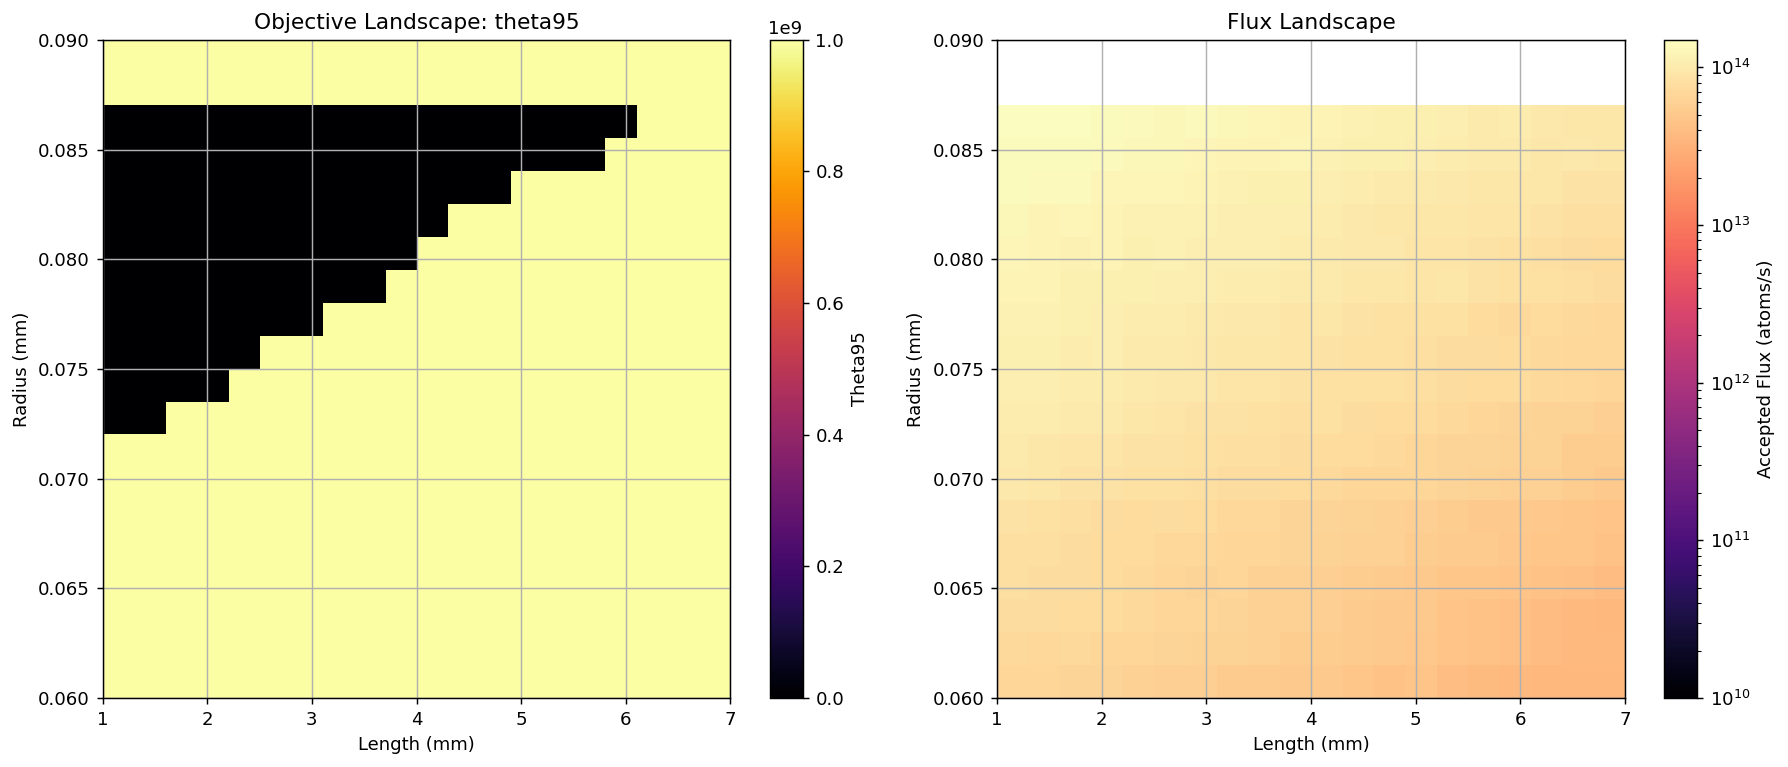

In [15]:
# Plotting Objective Function Landscape for Multi-Capillary Design with new function
radius_range = np.linspace(0.06, 0.09, 20)
length_range = np.linspace(1.0, 7.0, 20)

li.plot_objective_heatmap(radius_range, length_range, cfg, aperture_type='multi_capillary', min_flux=1e14)

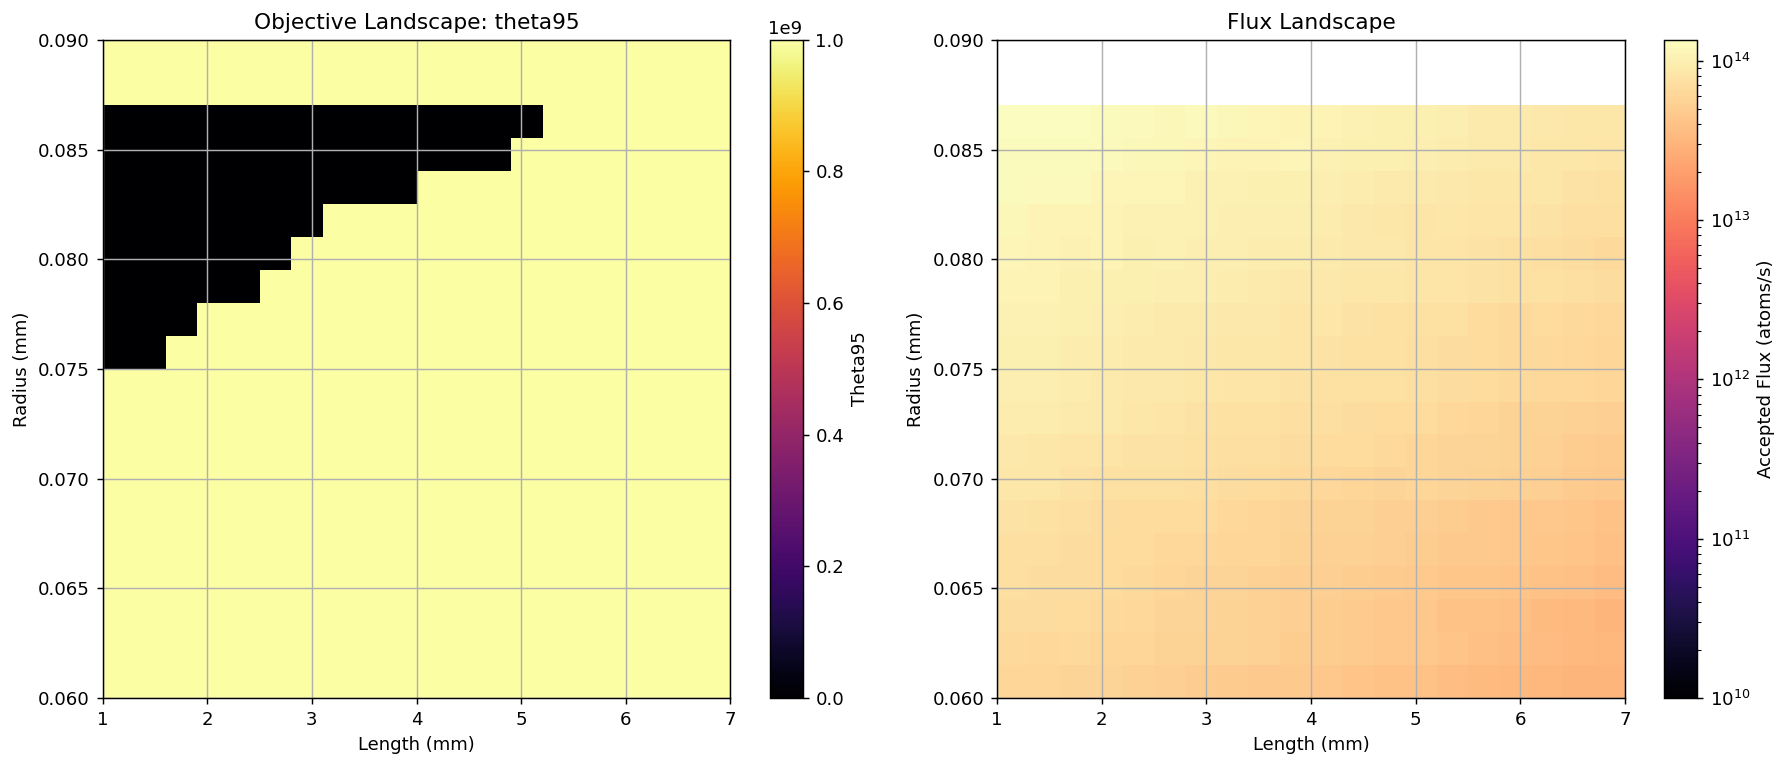

In [16]:
# Plotting Objective Function Landscape for Multi-Capillary Design with new function
radius_range = np.linspace(0.06, 0.09, 20)
length_range = np.linspace(1.0, 7.0, 20)

# Replacing oven temp with 600 C
cfg_local = replace(cfg, T_oven_C = 600.0)

li.plot_objective_heatmap(radius_range, length_range, cfg_local, aperture_type='multi_capillary', min_flux=1e14)

<unknown>:843: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<unknown>:843: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.


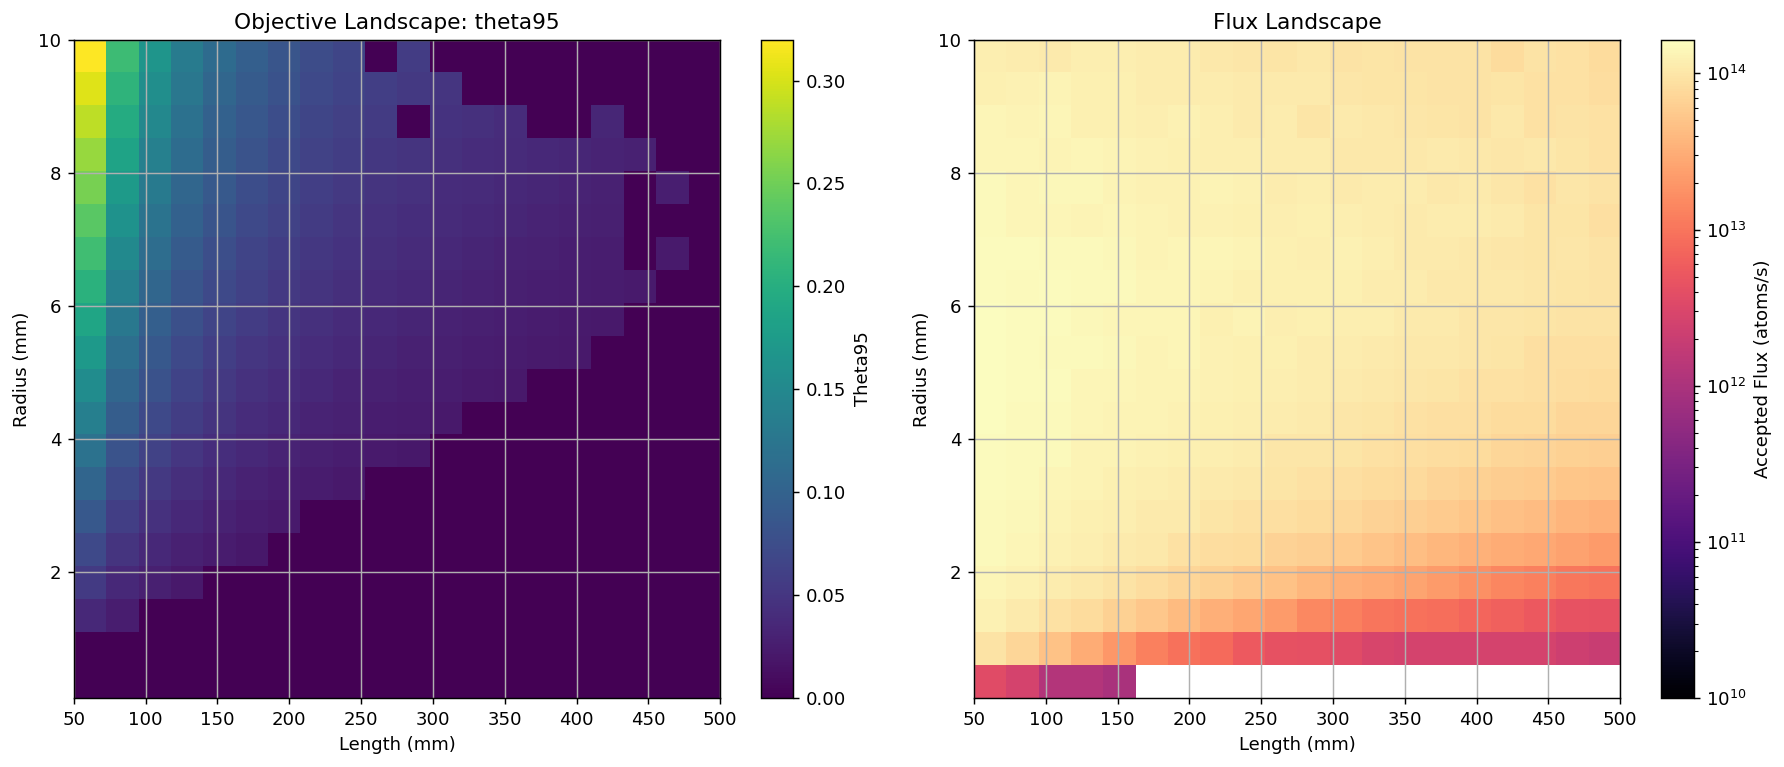

In [ ]:
# Plotting objective function landscape for long tube design
length_range = np.linspace(50, 500, 20)
radius_range = np.linspace(0.1, 10, 20)

# Using zero as punishment to see theta95 values better
li.plot_objective_heatmap(radius_range, length_range, cfg, aperture_type='long_tube', min_flux=1e14, punishment_value=-0.2)

Document from EIC with information on losses from input
Maybe need more than 10e13 flux

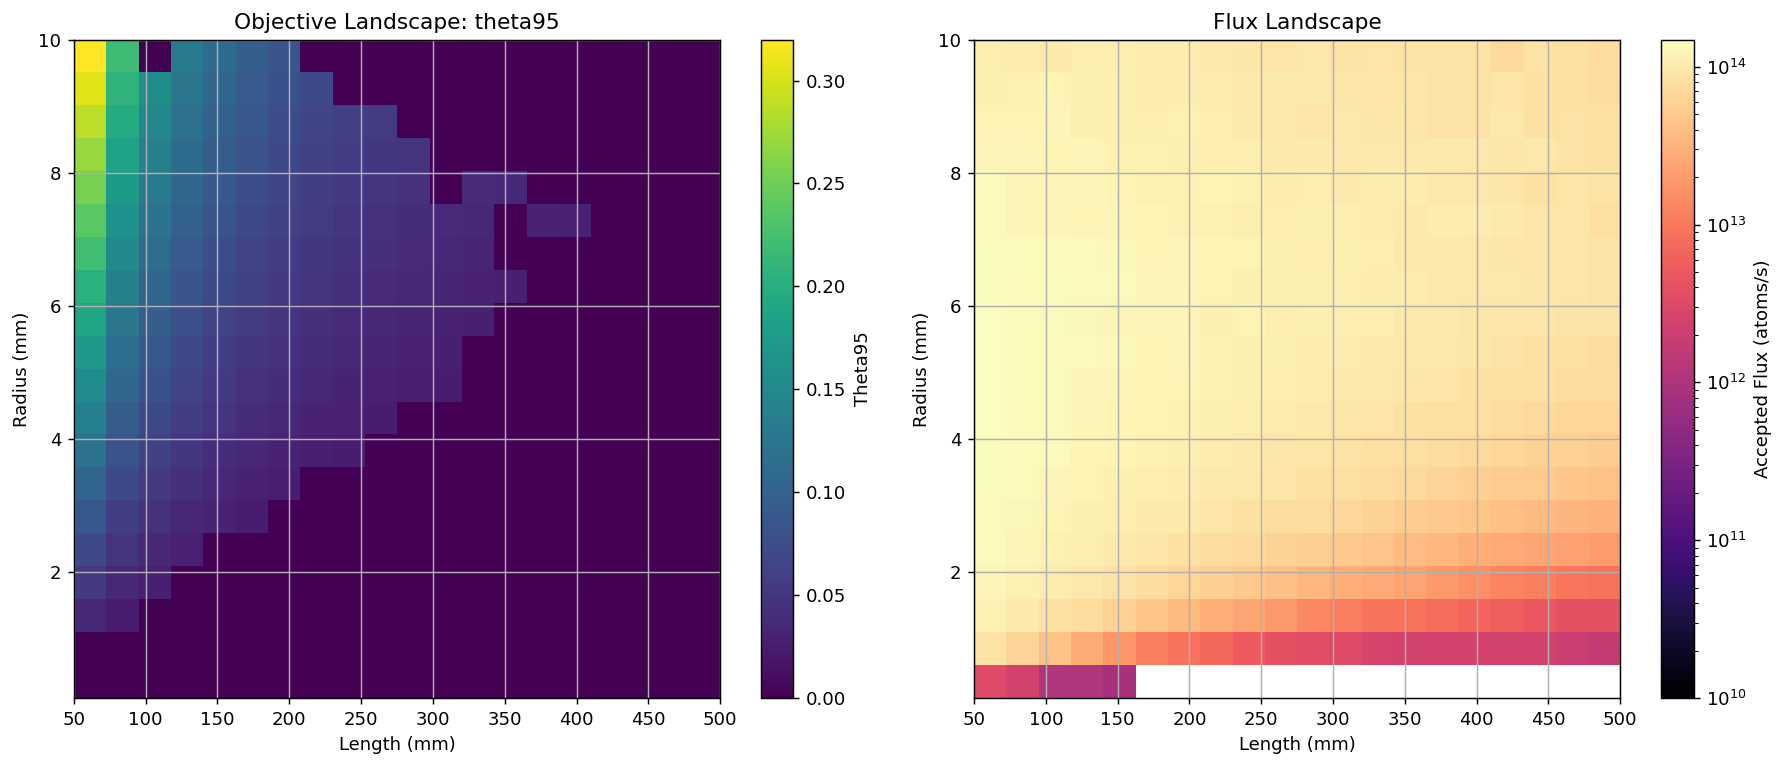

In [ ]:
# Repeating Long Tube for T_oven = 600 C
cfg_local = replace(cfg, T_oven_C = 600.0)

# Plotting objective function landscape for long tube design
length_range = np.linspace(50, 500, 20)
radius_range = np.linspace(0.1, 10, 20)

# Using zero as punishment to see theta95 values better
li.plot_objective_heatmap(radius_range, length_range, cfg_local, aperture_type='long_tube', min_flux=1e14, punishment_value=0)

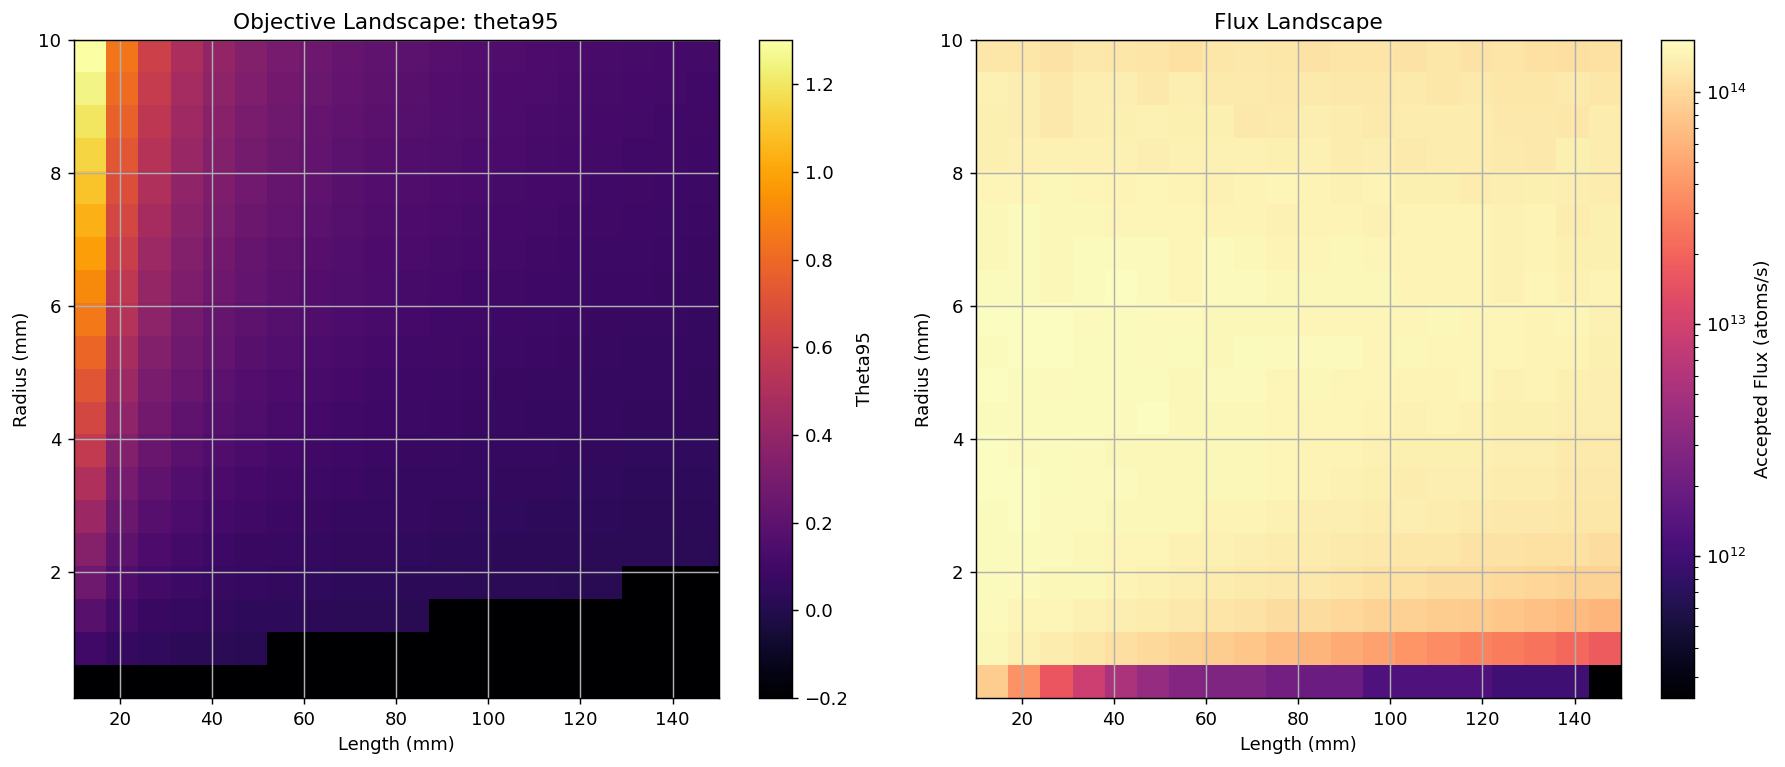

In [13]:
# Repeating Long Tube with physically reasonable parameters
# Plotting objective function landscape for long tube design
length_range = np.linspace(10, 150, 20)
radius_range = np.linspace(0.1, 10, 20)

# Using zero as punishment to see theta95 values better
li.plot_objective_heatmap(radius_range, length_range, cfg, aperture_type='long_tube', min_flux=1e14, punishment_value=-0.2)

add beam profiles at cooling entrances
mesh in the small radius tube?
Confirm max flux


7/22/26
* Added beam profiles at cooling entrances
* Added a function to calculate effusive source flux using Antoine's Law
    * this is why temperature was having a much weaker effect than expected, the effusive flux (vapor pressure) was remaining the same, only the velocity distributions were changing
* Updated the simulation to use Antoine's law
* Updated the flux calculations to include the flux immediately exiting the oven aperture
* Fixed flux calculation where it was not including the geometric probability of entering the aperture: factor = (aperture radius / oven channel radius) ^ 2
* Comparing the flux calculations with the projected figure on Korsch's slides verifies that we are likely underestimating the flux but a small amount (good thing)